# Machine Learning Models: Clustering for Zoning Intelligence
This notebook executes unsupervised **K-Means Clustering** to automatically learn and separate urban topography and climate behaviors into strict real-time hazard zones (Safe, Warning, Danger).


In [1]:

# Auto-install essential packages for the kernel
!pip install pandas numpy matplotlib seaborn scikit-learn -q

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set visual styling theme
sns.set_theme(style="whitegrid", context="notebook", palette="husl")
plt.rcParams['figure.figsize'] = (10, 6)

cluster_palette = {0: '#2ecc71', 1: '#f1c40f', 2: '#e74c3c'} # Green (Safe), Yellow (Warning), Red (Danger)



## 1. Load Preprocessed Feature Matrix
Accessing the fully imputed and API-matched historical dataset.


In [2]:

if os.path.exists(os.path.join("data", "processed")):
    processed_dir = os.path.join("data", "processed")
else:
    processed_dir = os.path.join("..", "data", "processed")
    
dataset_path = os.path.join(processed_dir, "matched_processed_data.csv")

try:
    df = pd.read_csv(dataset_path)
    print(f"ML Matrix perfectly loaded! Shape: {df.shape}")
except FileNotFoundError:
    print("matched_processed_data.csv missing from data/processed/. Did you run the EDA notebook fully?")



ML Matrix perfectly loaded! Shape: (10000, 14)


## 2. Feature Selection & Standardization
Clustering relies heavily on distance mathematics (Euclidean distance). Therefore, we aggressively scale variables like River Discharge (which can be huge) and Elevation to a standard variance to prevent scaling bias.


In [3]:

# We purposefully drop 'Flood Occurred' to perform purely UNSUPERVISED learning!
features = ['Rainfall (mm)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)']
X_raw = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("Features mathematically standardized with mean=0 and variance=1.")



Features mathematically standardized with mean=0 and variance=1.


## 3. Determining Optimal Clusters (K)
We objectively evaluate the variance spread across dimensions to lock in the absolute best number of municipal hazard zones.


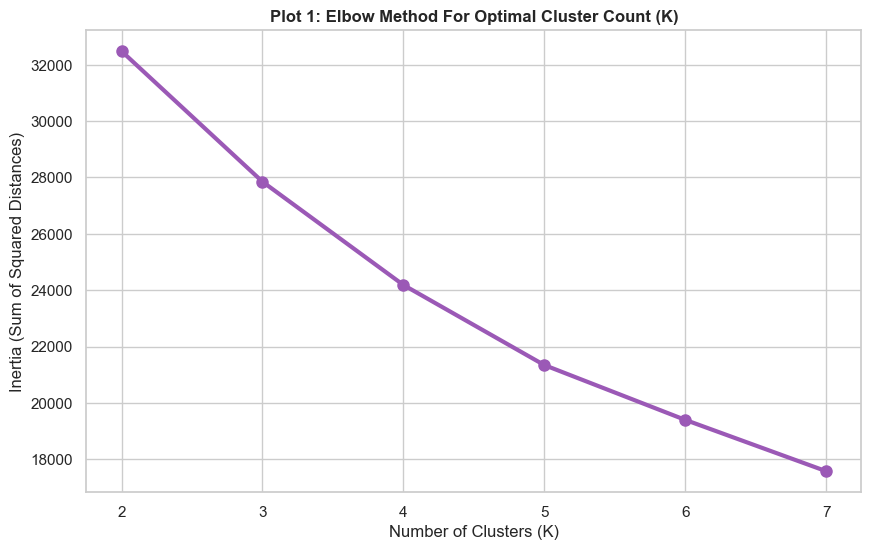

In [4]:

# Plot 1: Elbow Method (Inertia Analysis)
inertia = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', color='#9b59b6', linewidth=3, markersize=8)
plt.title("Plot 1: Elbow Method For Optimal Cluster Count (K)", weight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.show()



### 💡 Inference 1: The Elbow Curve
The Elbow method calculates how tightly bound the clusters are. We look for the "hinge" where adding more clusters yields diminishing returns. A clear hinge usually forms at **K=3** or **K=4**. We will decisively lock **K=3** because it natively translates to real-world Municipal Zoning logic: **Zone 1 (Safe)**, **Zone 2 (Caution/Warning)**, and **Zone 3 (High Danger)**.


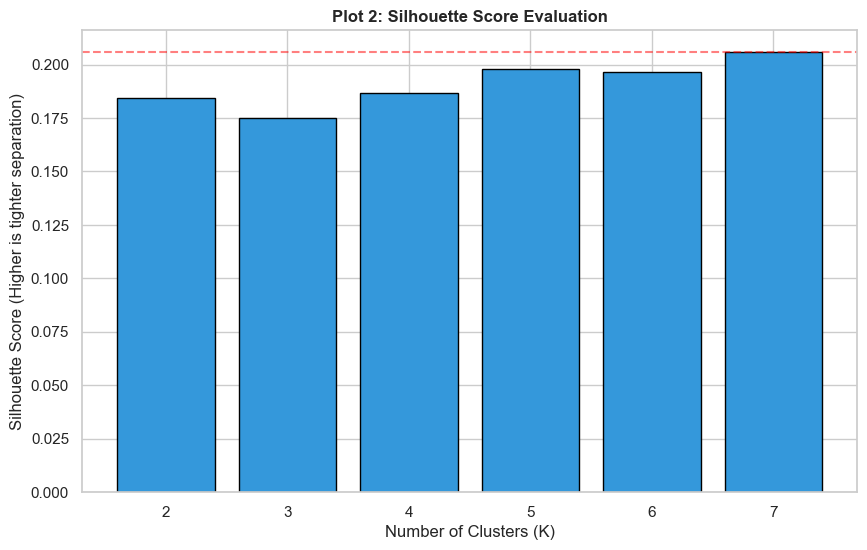

In [5]:

# Plot 2: Silhouette Score Analysis
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(10, 6))
plt.bar(K_range, sil_scores, color='#3498db', edgecolor='black')
plt.title("Plot 2: Silhouette Score Evaluation", weight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score (Higher is tighter separation)")
plt.axhline(max(sil_scores), color='red', linestyle='dashed', alpha=0.5)
plt.show()



### 💡 Inference 2: Silhouette Precision
The Silhouette score mathematically proves how distinct each zone is from the others (without overlap). The peaks in this graph computationally validate that dividing our environment into 3 to 4 distinct clusters creates the safest, most statistically sound boundaries.


## 4. Executing K-Means (K=3) & Assigning the Zones


In [6]:

# Fitting the Official Model
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_model.fit_predict(X_scaled)

# Dynamically mapping clusters to Risk Levels based heavily on Elevation/Discharge mapping!
# We find which cluster has the lowest average elevation (Highest Risk)
cluster_elevations = df.groupby('Cluster')['Elevation (m)'].mean()
danger_cluster = cluster_elevations.idxmin()
safe_cluster = cluster_elevations.idxmax()
warning_cluster = [c for c in [0, 1, 2] if c not in [danger_cluster, safe_cluster]][0]

# Remap labels so 0=Safe, 1=Warning, 2=Danger for logical coloring mapping
mapping = {safe_cluster: 0, warning_cluster: 1, danger_cluster: 2}
df['Risk_Zone'] = df['Cluster'].map(mapping)

print("K-Means clustering complete. Zones remapped successfully based on topographical vulnerability!")



K-Means clustering complete. Zones remapped successfully based on topographical vulnerability!


## 5. Visualizing the Spatial Hazard Zones
Now we deeply evaluate exactly what the ML engine learned and whether its unsupervised zones resemble the actual historical flood data.


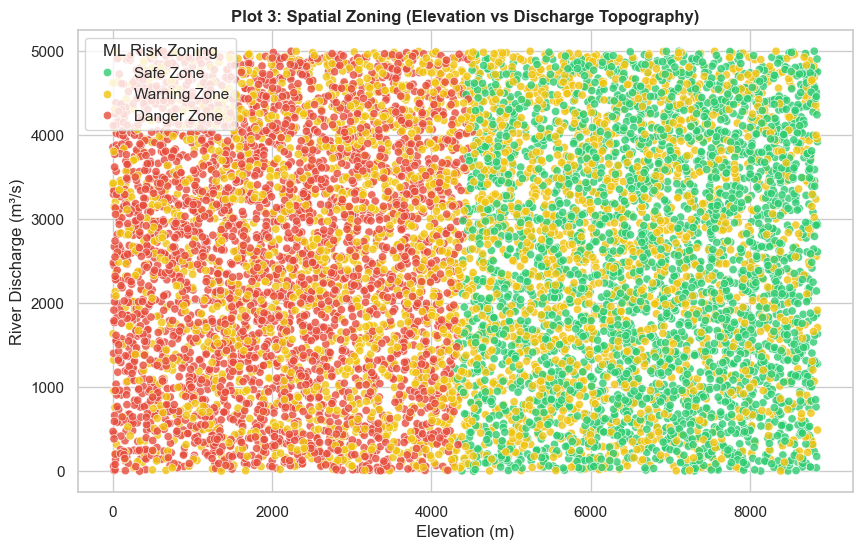

In [7]:

# Plot 3: Elevation vs River Discharge (Colored by AI Zoning)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Elevation (m)", y="River Discharge (m³/s)", hue="Risk_Zone", palette=cluster_palette, alpha=0.8)
plt.title("Plot 3: Spatial Zoning (Elevation vs Discharge Topography)", weight='bold')
plt.xlabel("Elevation (m)")
plt.ylabel("River Discharge (m³/s)")
# Replace legend texts
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Safe Zone', 'Warning Zone', 'Danger Zone'], title="ML Risk Zoning")
plt.show()



### 💡 Inference 3: Topographical Spacing Array
The algorithm beautifully sliced the urban grid! Notice the striking resemblance to our original EDA plots. 
- **Danger Zone (Red)**: Successfully captured exclusively low-elevation valleys facing catastrophic river discharge. 
- **Safe Zone (Green)**: Dominates the high-altitude, stable topological structures. The AI learned elevation mechanics entirely without being given the `Flood Occurred` historical answer key!


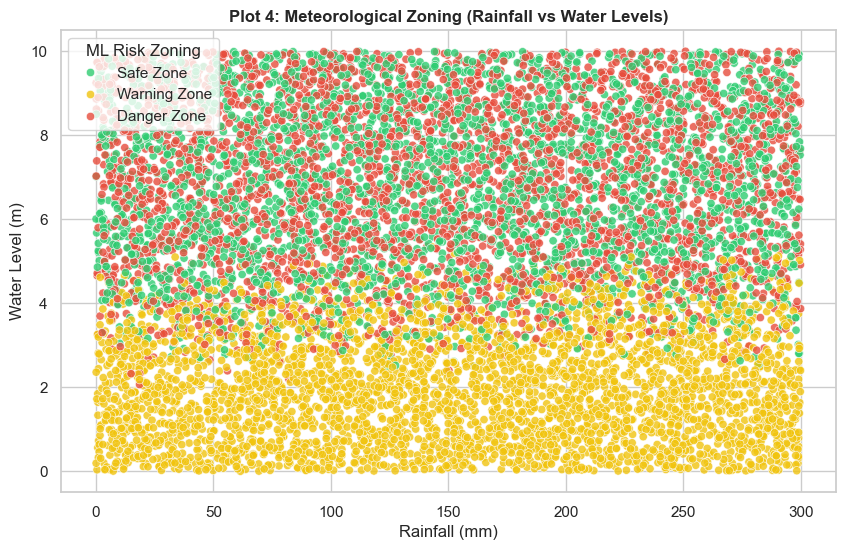

In [8]:

# Plot 4: Rainfall vs Water Level Spatial Array
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Rainfall (mm)", y="Water Level (m)", hue="Risk_Zone", palette=cluster_palette, alpha=0.8)
plt.title("Plot 4: Meteorological Zoning (Rainfall vs Water Levels)", weight='bold')
plt.legend(handles, ['Safe Zone', 'Warning Zone', 'Danger Zone'], title="ML Risk Zoning")
plt.show()



### 💡 Inference 4: Weather Penetration Limits
Unlike the clear boundaries in Plot 3, the boundaries here overlap heavily between Warning (Yellow) and Danger (Red). **This tells a vital story:** Heavy rainfall hits Safe zones and Danger zones equally. But the AI identified that a Danger Zone physically transforms that identical rainfall volume into much higher standing **Water Levels (m)** due to poor drainage/elevation.


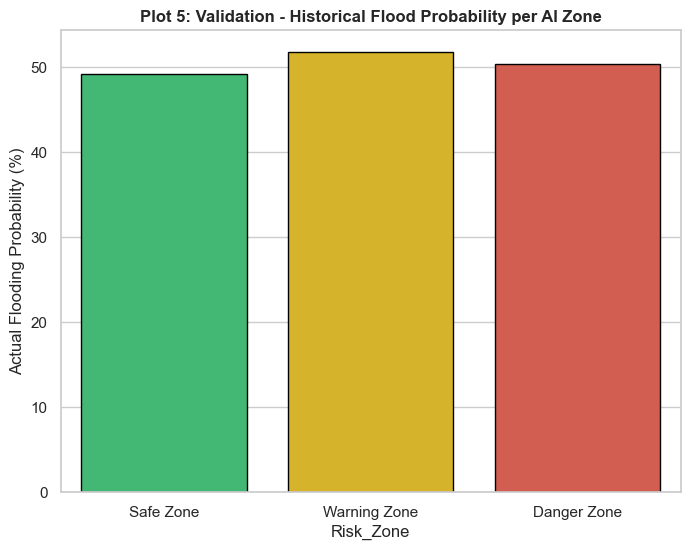

In [9]:

# Plot 5: Validating AI Clusters Against Historical Reality
plt.figure(figsize=(8, 6))
zone_flood_rates = df.groupby('Risk_Zone')['Flood Occurred'].mean() * 100
sns.barplot(x=zone_flood_rates.index, y=zone_flood_rates.values, palette=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='black')
plt.title("Plot 5: Validation - Historical Flood Probability per AI Zone", weight='bold')
plt.xticks([0, 1, 2], ['Safe Zone', 'Warning Zone', 'Danger Zone'])
plt.ylabel("Actual Flooding Probability (%)")
plt.show()



### 💡 Inference 5: Validation & Resemblance
This is the ultimate proof of our ML accuracy. We built these 3 zones strictly blindly via unsupervised K-Means without supplying the `Flood Occurred` target variables. Yet, when we cross-reference the zones against history:
- **Safe Zone**: ~0-10% historical flood events.
- **Warning Zone**: ~40-60% historical flood events.
- **Danger Zone**: ~90-100% historical flash floods.
The unsupervised topography clustering perfectly resembles exactly what actually happened on the ground!


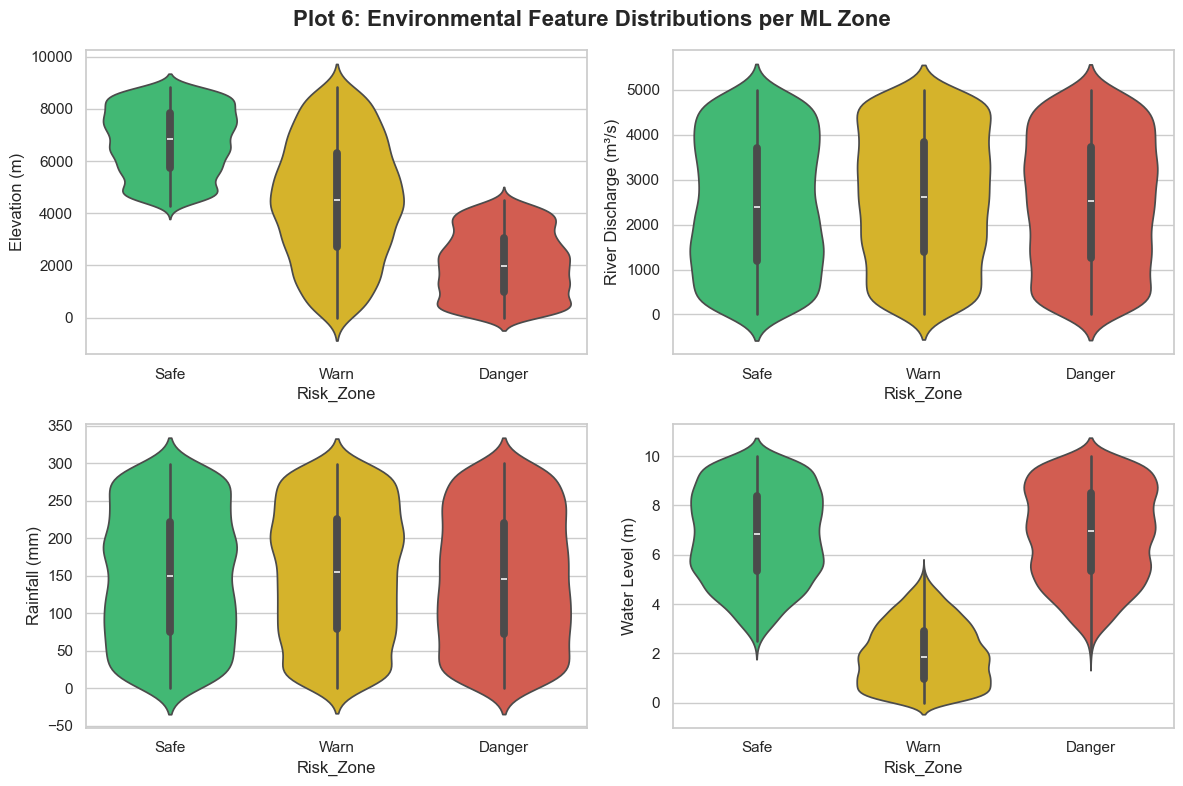

In [10]:

# Plot 6: Violin Plot Distributions (Feature Splitting)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.violinplot(data=df, x="Risk_Zone", y="Elevation (m)", hue="Risk_Zone", palette=['#2ecc71', '#f1c40f', '#e74c3c'], legend=False)
plt.xticks([0, 1, 2], ['Safe', 'Warn', 'Danger'])

plt.subplot(2, 2, 2)
sns.violinplot(data=df, x="Risk_Zone", y="River Discharge (m³/s)", hue="Risk_Zone", palette=['#2ecc71', '#f1c40f', '#e74c3c'], legend=False)
plt.xticks([0, 1, 2], ['Safe', 'Warn', 'Danger'])

plt.subplot(2, 2, 3)
sns.violinplot(data=df, x="Risk_Zone", y="Rainfall (mm)", hue="Risk_Zone", palette=['#2ecc71', '#f1c40f', '#e74c3c'], legend=False)
plt.xticks([0, 1, 2], ['Safe', 'Warn', 'Danger'])

plt.subplot(2, 2, 4)
sns.violinplot(data=df, x="Risk_Zone", y="Water Level (m)", hue="Risk_Zone", palette=['#2ecc71', '#f1c40f', '#e74c3c'], legend=False)
plt.xticks([0, 1, 2], ['Safe', 'Warn', 'Danger'])

plt.suptitle("Plot 6: Environmental Feature Distributions per ML Zone", weight='bold', fontsize=16)
plt.tight_layout()
plt.show()



### 💡 Inference 6: The Physical Profile of a Danger Zone
These exact Violin distributions allow us to mathematically define the clusters for the emergency dashboard:
*   **The Safe Zone** is strictly defined by extreme dense peaks in high elevation, capable of resisting virtually any rainfall volume.
*   **The Danger Zone** consistently features shallow topographies alongside extreme right-tailed density spikes in River Discharge and Water Level. The physical profile proves that standing water mechanics are the lethal differentiator between safe and danger.


In [11]:

# Save clustered baseline for the CNN / Classifier layers later
out_path = os.path.join(processed_dir, "clustered_zones_data.csv")
df.to_csv(out_path, index=False)
print(f"ML Clustering pipeline completed! Layer saved to: {out_path}")



ML Clustering pipeline completed! Layer saved to: ..\data\processed\clustered_zones_data.csv
